# Day 12 — Revision & Pipeline Practice

After a short gap, this notebook focuses on revising key concepts and building a basic data processing pipeline.



In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame({ 
    "study_hours":[1,2,3,4,5,6,7,8],
    "marks":[35,40,50,60,65,70,80,90]
})


In [7]:
df.describe()

,study_hours,marks
count,8.00000,8.000000
mean,4.50000,61.250000
std,2.44949,19.039433
min,1.00000,35.000000
25%,2.75000,47.500000
50%,4.50000,62.500000
75%,6.25000,72.500000
max,8.00000,90.000000


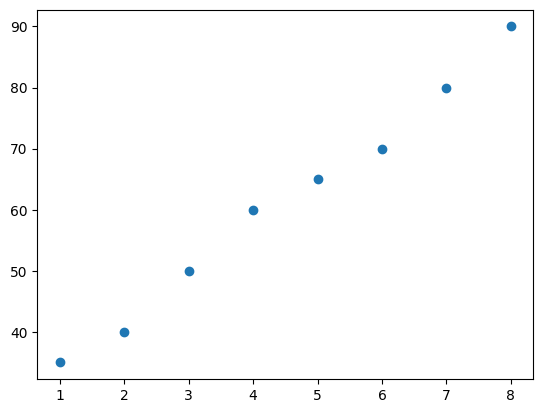

In [8]:
plt.scatter(df['study_hours'],df['marks'])
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression

x = df[['study_hours']]
y = df[['marks']]

model = LinearRegression()
model.fit(x,y)
pred = model.predict(x)


In [11]:
from sklearn.metrics import mean_absolute_error
print("MAE:",mean_absolute_error(y,pred))

MAE: 1.3690476190476204


In [15]:
model.predict([[9]])

C:\Users\susha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[96.07142857]])

In [20]:
df['pass'] = (df['marks']>=50).astype(int)

In [21]:
df

,study_hours,marks,pass
0,1,35,0
1,2,40,0
2,3,50,1
3,4,60,1
4,5,65,1
5,6,70,1
6,7,80,1
7,8,90,1


In [24]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression()
y_pass = df[['pass']]
model1.fit(x,y_pass)

pred1 = model1.predict(x)



C:\Users\susha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [30]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_pass,pred1))
print(classification_report(y_pass,pred1))


[[2 0]
 [0 6]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         6

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [32]:
data = pd.DataFrame({
    'study_hours':[1,2,3,4,5,6,7,8,9,10],
    'attendance':[50,55,60, 65,70,75,80,85,90,95],
    'marks':[35,40,45,55,60,65,70, 80,85,90]})

data

,study_hours,attendance,marks
0,1,50,35
1,2,55,40
2,3,60,45
3,4,65,55
4,5,70,60
5,6,75,65
6,7,80,70
7,8,85,80
8,9,90,85
9,10,95,90


In [33]:
data.describe()

,study_hours,attendance,marks
count,10.00000,10.000000,10.000000
mean,5.50000,72.500000,62.500000
std,3.02765,15.138252,19.039433
min,1.00000,50.000000,35.000000
25%,3.25000,61.250000,47.500000
50%,5.50000,72.500000,62.500000
75%,7.75000,83.750000,77.500000
max,10.00000,95.000000,90.000000


In [34]:
data.corr()

,study_hours,attendance,marks
study_hours,1.000000,1.000000,0.997489
attendance,1.000000,1.000000,0.997489
marks,0.997489,0.997489,1.000000


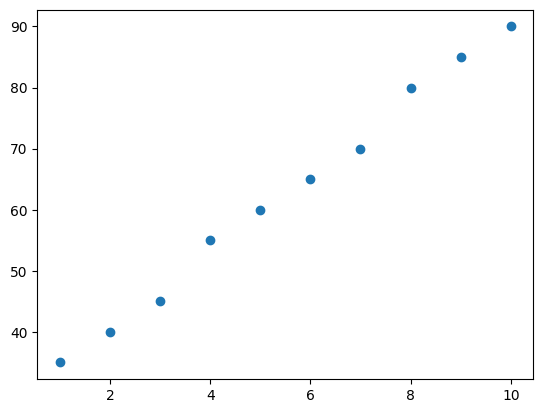

In [35]:
plt.scatter(data['study_hours'],data['marks'])
plt.show()

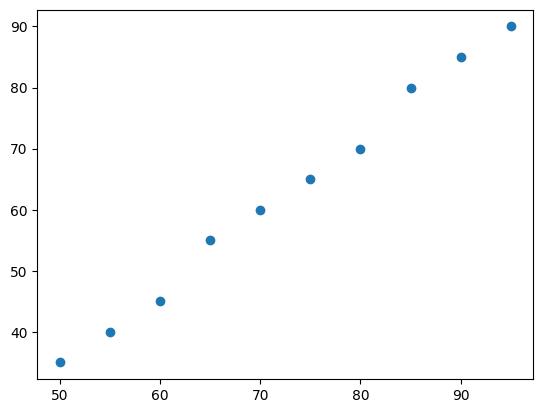

In [37]:
plt.scatter(data['attendance'],data['marks'])
plt.show()

In [46]:
from sklearn.linear_model import LinearRegression

linear_model_st = LinearRegression()
x_st = data[['study_hours']]
y_marks = data[['marks']]

linear_model_st.fit(x_st,y_marks)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
predict_st = linear_model.predict(x_st)
print(predict_st)

[[34.27272727]
 [40.54545455]
 [46.81818182]
 [53.09090909]
 [59.36363636]
 [65.63636364]
 [71.90909091]
 [78.18181818]
 [84.45454545]
 [90.72727273]]


In [48]:
from sklearn.metrics import mean_absolute_error

print("MAE:",mean_absolute_error(y_marks,predict))

MAE: 1.1272727272727259


In [50]:
linear_model_atd = LinearRegression()
x_atd = data[['attendance']]
linear_model_atd.fit(x_atd,y_marks)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [54]:
predict_atd = linear_model_atd.predict(x_atd)
predict_atd

array([[34.27272727],
       [40.54545455],
       [46.81818182],
       [53.09090909],
       [59.36363636],
       [65.63636364],
       [71.90909091],
       [78.18181818],
       [84.45454545],
       [90.72727273]])

In [55]:
print("MAE:",mean_absolute_error(x_atd,predict_atd))

MAE: 10.000000000000007


In [60]:
data['pass'] = (data['marks']>=50).astype(int)

In [61]:
data

,study_hours,attendance,marks,pass
0,1,50,35,0
1,2,55,40,0
2,3,60,45,0
3,4,65,55,1
4,5,70,60,1
5,6,75,65,1
6,7,80,70,1
7,8,85,80,1
8,9,90,85,1
9,10,95,90,1


In [66]:
from sklearn.linear_model import LogisticRegression

X = df[['study_hours']]     
y = df['pass']              

logistic_model_st = LogisticRegression()
logistic_model_st.fit(X, y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [68]:
predict_st_log = logistic_model_st.predict(X)


In [71]:
from sklearn.metrics import confusion_matrix,classification_report

print(confusion_matrix(y,predict_st_log))

[[2 0]
 [0 6]]


In [72]:
print(classification_report(y,predict_st_log))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         6

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [76]:
logistic_model_at = LogisticRegression()
x_atd = data[['attendance']]
y = data['pass'] 
logistic_model_at.fit(x_atd,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [77]:
predict_logistic_at = logistic_model_at.predict(x_atd)


In [78]:
print(confusion_matrix(y,predict_logistic_at))
print(classification_report(y,predict_logistic_at))

[[3 0]
 [0 7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

